# Model V7 — Validation Upgrade + Feature Diagnosis

This notebook is used to upgrade the validation framework from earlier phase-1 models.

## Main goals
1. Use a more stable repeated cross-validation framework.
2. Apply stratified splitting by `mechanism_simple`.
3. Diagnose whether additional features provide independent information.
4. Compare core model vs. diagnostic feature sets.
5. Evaluate whether some variables are true drivers, proxy variables, or noisy/confounded variables.

In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import warnings

warnings.filterwarnings("ignore")

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    train_test_split,
    StratifiedShuffleSplit,
    cross_validate
)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [2]:
# Load cleaned phase-1 dataset
df_clean = pd.read_csv("hydrovoltaic_clean_phase1.csv")

print(df_clean.shape)
df_clean.head()

(183, 50)


,paper_doi,review_covered,ref_year,device_structure,built_in_asymmetry,asymmetry_origin,primary_mobile_ion,secondary_ion_present,secondary_mobile_ion,ion_origin,auxiliary_redox_present,continuous_output,water_interaction_mode,rh_percent,inorganic_electrolyte_present,inorganic_electrolyte_type,inorganic_electrolyte_concentration_wt%,polyelectrolyte_present,active_material_raw,material_class,structure_class,ionic_groups,top_electrode,bottom_electrode,electrode_symmetry,metal_electrode,voc_V,jsc_uA_cm2,power_density_uW_cm2,internal_resistance_MΩ,output_timescale_class,stability_time_min,dominant_mechanism,has_anionic,has_cationic,has_zwitterionic,polyelectrolyte_anionic_raw,polyelectrolyte_cationic_raw,polyelectrolyte_zwitterionic_raw,has_any_polyelectrolyte,estimated_power_density_uW_cm2,log_estimated_power_density,ion_type,asym_env,asym_chem,asym_electrode,mechanism_simple,ion_from_material,ion_from_electrolyte,ion_from_water
0,10.1038/nnano.2016.300,1,2017,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,60.0,0,NaN,NaN,0,Carbon Black (CB),carbon,porous,"carboxyl, hydroxyl",CNT,CNT,1,0.0,1.00,0.0150,0.0053,8.0,days,11520.0,streaming,0,0,0,NaN,NaN,NaN,0,0.003750,-2.425853,proton,1,0,0,streaming,1,0,0
1,10.1021/acsaelm.9b00419,1,2019,in-plane,0,environmental_gradient,OH-,1,H+,water_dissociation,0,1,evaporation_driven,62.0,0,NaN,NaN,0,ZnO,metal oxide,porous,hydroxyl,Al,Al,1,1.0,0.40,0.0200,0.0020,34.3,hours,120.0,streaming,0,0,0,NaN,NaN,NaN,0,0.002000,-2.698753,anion,1,0,0,streaming,0,0,1
2,10.1002/adma.202514202,0,2026,in-plane,1,chemical + environmental,OH-,1,H+,water_dissociation,0,1,evaporation_driven,NaN,0,NaN,NaN,0,lanthanum iron perovskite oxide,semiconductor,porous,hydroxyl,CNT,CNT,1,0.0,1.50,0.0250,0.0094,60.0,days,12000.0,streaming,0,0,0,NaN,NaN,NaN,0,0.009375,-2.027982,anion,1,1,0,streaming,0,0,1
3,10.1016/j.joule.2022.02.002,1,2022,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,NaN,0,NaN,NaN,0,Carbon Black (CB),carbon,porous,"carboxyl, hydroxyl",CNT,CNT,1,0.0,0.85,0.0368,NaN,NaN,hours,720.0,streaming,0,0,0,NaN,NaN,NaN,0,0.007820,-2.106738,proton,1,0,0,streaming,1,0,0
4,10.1016/j.ceramint.2023.05.033,0,2023,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,55.0,0,NaN,NaN,0,carbonized rice husk,carbon,porous,"carboxyl, hydroxyl, silanol",CNT,CNT,1,0.0,0.16,0.0400,NaN,NaN,hours,600.0,streaming,0,0,0,NaN,NaN,NaN,0,0.001600,-2.795609,proton,1,0,0,streaming,1,0,0


In [3]:
# Basic check
print("Columns in df_clean:")
print(df_clean.columns.tolist())

Columns in df_clean:
['paper_doi', 'review_covered', 'ref_year', 'device_structure', 'built_in_asymmetry', 'asymmetry_origin', 'primary_mobile_ion', 'secondary_ion_present', 'secondary_mobile_ion', 'ion_origin', 'auxiliary_redox_present', 'continuous_output', 'water_interaction_mode', 'rh_percent', 'inorganic_electrolyte_present', 'inorganic_electrolyte_type', 'inorganic_electrolyte_concentration_wt%', 'polyelectrolyte_present', 'active_material_raw', 'material_class', 'structure_class', 'ionic_groups', 'top_electrode', 'bottom_electrode', 'electrode_symmetry', 'metal_electrode', 'voc_V', 'jsc_uA_cm2', 'power_density_uW_cm2', 'internal_resistance_MΩ', 'output_timescale_class', 'stability_time_min', 'dominant_mechanism', 'has_anionic', 'has_cationic', 'has_zwitterionic', 'polyelectrolyte_anionic_raw', 'polyelectrolyte_cationic_raw', 'polyelectrolyte_zwitterionic_raw', 'has_any_polyelectrolyte', 'estimated_power_density_uW_cm2', 'log_estimated_power_density', 'ion_type', 'asym_env', 'asy

## Why V7?

Earlier phase-1 models provided useful initial results, but several methodological limitations remained:

- cross-validation used only a small number of repeated random splits
- no explicit stratification by mechanism
- feature effects may be unstable across different train/test splits
- some variables may act as proxy variables rather than independent drivers

Model V7 is designed to address these issues through validation upgrade and feature diagnosis.

In [4]:
# Prepare V7 dataset
df_v7 = df_clean.copy()

# Keep only rows with target and mechanism label
df_v7 = df_v7.dropna(subset=["log_estimated_power_density", "mechanism_simple"]).copy()

# Internal resistance transformation
# Use log10 to reduce skewness
df_v7["log_internal_resistance_Mohm"] = np.where(
    df_v7["internal_resistance_MΩ"] > 0,
    np.log10(df_v7["internal_resistance_MΩ"]),
    np.nan
)

# Missingness indicator for internal resistance
df_v7["has_internal_resistance"] = df_v7["internal_resistance_MΩ"].notna().astype(int)

print("V7 dataset shape:", df_v7.shape)
print("\nMechanism distribution:")
print(df_v7["mechanism_simple"].value_counts(dropna=False))

print("\nMissing internal resistance:")
print(df_v7["log_internal_resistance_Mohm"].isna().sum())

V7 dataset shape: (159, 52)

Mechanism distribution:
mechanism_simple
ion_gradient    107
streaming        52
Name: count, dtype: int64

Missing internal resistance:
47


In [5]:
# Define target
TARGET = "log_estimated_power_density"
STRATIFY_COL = "mechanism_simple"

In [6]:
# =========================
# V7 feature sets
# =========================

features_v7_core = [
    "material_class",
    "structure_class",
    "built_in_asymmetry",
    "inorganic_electrolyte_present",
    "polyelectrolyte_present",
    "has_anionic",
    "has_cationic",
    "has_zwitterionic",
    "mechanism_simple",
    "water_interaction_mode",
    "top_electrode",
    "bottom_electrode",
    "electrode_symmetry",
    "metal_electrode",
    "ionic_groups",
    "ion_type"
]

features_v7_device = features_v7_core + [
    "device_structure"
]

features_v7_asym = features_v7_core + [
    "asym_env",
    "asym_chem",
    "asym_electrode"
]

features_v7_ion_origin = features_v7_core + [
    "ion_from_material",
    "ion_from_electrolyte",
    "ion_from_water"
]

features_v7_internalR = features_v7_core + [
    "log_internal_resistance_Mohm",
    "has_internal_resistance"
]

features_v7_all_diag = features_v7_core + [
    "device_structure",
    "asym_env",
    "asym_chem",
    "asym_electrode",
    "ion_from_material",
    "ion_from_electrolyte",
    "ion_from_water",
    "log_internal_resistance_Mohm",
    "has_internal_resistance"
]

feature_sets_v7 = {
    "V7_core": features_v7_core,
    "V7_device": features_v7_device,
    "V7_asym": features_v7_asym,
    "V7_ion_origin": features_v7_ion_origin,
    "V7_internalR": features_v7_internalR,
    "V7_all_diag": features_v7_all_diag
}

for name, feats in feature_sets_v7.items():
    print(f"{name}: {len(feats)} raw columns")

V7_core: 16 raw columns
V7_device: 17 raw columns
V7_asym: 19 raw columns
V7_ion_origin: 19 raw columns
V7_internalR: 18 raw columns
V7_all_diag: 25 raw columns


In [7]:
# Helper function: split categorical/numeric
def split_feature_types(df_input, features):
    categorical_features = []
    numeric_features = []

    for col in features:
        if pd.api.types.is_numeric_dtype(df_input[col]):
            numeric_features.append(col)
        else:
            categorical_features.append(col)

    return categorical_features, numeric_features

In [8]:
# Helper function: build pipeline
def build_rf_pipeline(df_input, features, random_state=42):
    categorical_features, numeric_features = split_feature_types(df_input, features)

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, categorical_features),
            ("num", numeric_transformer, numeric_features)
        ],
        remainder="drop"
    )

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=random_state,
        n_jobs=-1
    )

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    return pipeline, categorical_features, numeric_features

In [9]:
# Main evaluation function
def evaluate_rf_model_v7(
    df_input,
    features,
    target=TARGET,
    stratify_col=STRATIFY_COL,
    model_name="V7_model",
    n_splits=50,
    test_size=0.2,
    holdout_random_state=42
):
    # Remove duplicate column names if stratify_col already exists in features
    all_cols = list(dict.fromkeys(features + [target, stratify_col]))
    df_model = df_input[all_cols].copy()

    X = df_model[features]
    y = df_model[target]
    strata = df_model[stratify_col]

    pipeline, categorical_features, numeric_features = build_rf_pipeline(df_model, features)

    # One holdout split for predicted-vs-true plot and SHAP
    X_train, X_test, y_train, y_test, strata_train, strata_test = train_test_split(
        X, y, strata,
        test_size=test_size,
        random_state=holdout_random_state,
        stratify=strata
    )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    holdout_r2 = r2_score(y_test, y_pred)
    holdout_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    holdout_mae = mean_absolute_error(y_test, y_pred)

    # Repeated stratified CV
    sss = StratifiedShuffleSplit(
        n_splits=n_splits,
        test_size=test_size,
        random_state=holdout_random_state
    )

    cv_results = cross_validate(
        pipeline,
        X,
        y,
        cv=sss.split(X, strata),
        scoring={
            "r2": "r2",
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error"
        },
        return_train_score=False,
        n_jobs=-1
    )

    cv_r2 = cv_results["test_r2"]
    cv_rmse = -cv_results["test_rmse"]
    cv_mae = -cv_results["test_mae"]

    fitted_preprocessor = pipeline.named_steps["preprocessor"]
    feature_names = fitted_preprocessor.get_feature_names_out()

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": pipeline.named_steps["model"].feature_importances_
    }).sort_values("importance", ascending=False)

    print(f"\n===== {model_name} =====")
    print("Rows used:", len(df_model))
    print("Raw features:", len(features))
    print("Encoded features:", len(feature_names))
    print(f"Holdout R2: {holdout_r2:.4f}")
    print(f"Holdout RMSE: {holdout_rmse:.4f}")
    print(f"Holdout MAE: {holdout_mae:.4f}")
    print(f"CV R2 mean ± std: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print(f"CV R2 min / max: {cv_r2.min():.4f} / {cv_r2.max():.4f}")

    return {
        "model_name": model_name,
        "features": features,
        "df_model": df_model,
        "X": X,
        "y": y,
        "strata": strata,
        "pipeline": pipeline,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred,
        "holdout_r2": holdout_r2,
        "holdout_rmse": holdout_rmse,
        "holdout_mae": holdout_mae,
        "cv_r2": cv_r2,
        "cv_rmse": cv_rmse,
        "cv_mae": cv_mae,
        "cv_results": cv_results,
        "importance_df": importance_df,
        "feature_names": feature_names,
        "categorical_features": categorical_features,
        "numeric_features": numeric_features
    }

In [10]:
# Summary function
def summarize_v7_results(result_dict):
    rows = []

    for name, res in result_dict.items():
        rows.append({
            "Model": name,
            "Rows_used": len(res["df_model"]),
            "Raw_features": len(res["features"]),
            "Encoded_features": len(res["feature_names"]),
            "Holdout_R2": res["holdout_r2"],
            "Holdout_RMSE": res["holdout_rmse"],
            "Holdout_MAE": res["holdout_mae"],
            "CV_R2_mean": res["cv_r2"].mean(),
            "CV_R2_std": res["cv_r2"].std(),
            "CV_R2_min": res["cv_r2"].min(),
            "CV_R2_max": res["cv_r2"].max(),
            "CV_RMSE_mean": res["cv_rmse"].mean(),
            "CV_MAE_mean": res["cv_mae"].mean()
        })

    return pd.DataFrame(rows).sort_values("CV_R2_mean", ascending=False).reset_index(drop=True)

In [11]:
# Plot CV distribution
def plot_cv_r2_distributions(result_dict, figsize=(10, 5)):
    plt.figure(figsize=figsize)

    data_to_plot = [res["cv_r2"] for res in result_dict.values()]
    labels = list(result_dict.keys())

    plt.boxplot(data_to_plot, labels=labels, vert=True)
    plt.ylabel("CV R2")
    plt.title("Model V7: Distribution of Stratified CV R2")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

In [12]:
# Plot predicted vs true
def plot_pred_vs_true(result, title_suffix=""):
    plt.figure(figsize=(5, 5))
    plt.scatter(result["y_test"], result["y_pred"], alpha=0.7)

    min_val = min(result["y_test"].min(), result["y_pred"].min())
    max_val = max(result["y_test"].max(), result["y_pred"].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel("True log(Power Density)")
    plt.ylabel("Predicted log(Power Density)")
    plt.title(f'{result["model_name"]}: True vs Predicted {title_suffix}')
    plt.tight_layout()
    plt.show()

In [13]:
# Plot feature importance
def plot_top_importance(result, top_n=15):
    top_df = result["importance_df"].head(top_n).iloc[::-1]

    plt.figure(figsize=(7, max(4, top_n * 0.3)))
    plt.barh(top_df["feature"], top_df["importance"])
    plt.xlabel("Random Forest Importance")
    plt.title(f'Top {top_n} Features — {result["model_name"]}')
    plt.tight_layout()
    plt.show()

In [14]:
# Fair comparison for internal resistance
def fair_internalR_comparison(df_input, base_features, target=TARGET):
    subset = df_input.dropna(subset=["log_internal_resistance_Mohm"]).copy()

    print("Rows in fair internal-R subset:", len(subset))

    res_base = evaluate_rf_model_v7(
        df_input=subset,
        features=base_features,
        target=target,
        stratify_col=STRATIFY_COL,
        model_name="V7_core_on_internalR_subset"
    )

    res_plusR = evaluate_rf_model_v7(
        df_input=subset,
        features=base_features + ["log_internal_resistance_Mohm"],
        target=target,
        stratify_col=STRATIFY_COL,
        model_name="V7_core_plus_internalR_on_same_subset"
    )

    return {
        "base_same_subset": res_base,
        "plusR_same_subset": res_plusR
    }

In [15]:
# Run all V7 models
results_v7 = {}

for model_name, feat_list in feature_sets_v7.items():
    results_v7[model_name] = evaluate_rf_model_v7(
        df_input=df_v7,
        features=feat_list,
        target=TARGET,
        stratify_col=STRATIFY_COL,
        model_name=model_name,
        n_splits=50,
        test_size=0.2,
        holdout_random_state=42
    )


===== V7_core =====
Rows used: 159
Raw features: 16
Encoded features: 90
Holdout R2: 0.3365
Holdout RMSE: 1.1621
Holdout MAE: 0.9177
CV R2 mean ± std: 0.1078 ± 0.2072
CV R2 min / max: -0.5967 / 0.4097

===== V7_device =====
Rows used: 159
Raw features: 17
Encoded features: 93
Holdout R2: 0.3407
Holdout RMSE: 1.1585
Holdout MAE: 0.9193
CV R2 mean ± std: 0.1390 ± 0.1805
CV R2 min / max: -0.4158 / 0.4478

===== V7_asym =====
Rows used: 159
Raw features: 19
Encoded features: 93
Holdout R2: 0.3132
Holdout RMSE: 1.1824
Holdout MAE: 0.9505
CV R2 mean ± std: 0.1099 ± 0.2055
CV R2 min / max: -0.5861 / 0.4274

===== V7_ion_origin =====
Rows used: 159
Raw features: 19
Encoded features: 93
Holdout R2: 0.3152
Holdout RMSE: 1.1806
Holdout MAE: 0.9333
CV R2 mean ± std: 0.0944 ± 0.2115
CV R2 min / max: -0.5978 / 0.3962

===== V7_internalR =====
Rows used: 159
Raw features: 18
Encoded features: 92
Holdout R2: 0.3600
Holdout RMSE: 1.1414
Holdout MAE: 0.8702
CV R2 mean ± std: 0.1847 ± 0.1544
CV R2 min /

In [16]:
# Summary table
summary_v7 = summarize_v7_results(results_v7)
summary_v7

,Model,Rows_used,Raw_features,Encoded_features,Holdout_R2,Holdout_RMSE,Holdout_MAE,CV_R2_mean,CV_R2_std,CV_R2_min,CV_R2_max,CV_RMSE_mean,CV_MAE_mean
0,V7_internalR,159,18,92,0.359988,1.141379,0.870170,0.184738,0.154366,-0.185310,0.448731,1.155622,0.888459
1,V7_all_diag,159,25,101,0.349480,1.150711,0.873502,0.175285,0.151874,-0.153313,0.428899,1.162600,0.898030
2,V7_device,159,17,93,0.340674,1.158474,0.919306,0.139048,0.180463,-0.415804,0.447808,1.186657,0.922425
3,V7_asym,159,19,93,0.313197,1.182366,0.950539,0.109862,0.205504,-0.586127,0.427414,1.204593,0.929816
4,V7_core,159,16,90,0.336525,1.162113,0.917652,0.107835,0.207183,-0.596669,0.409744,1.205558,0.922195
5,V7_ion_origin,159,19,93,0.315223,1.180621,0.933325,0.094434,0.211461,-0.597800,0.396155,1.214294,0.929900


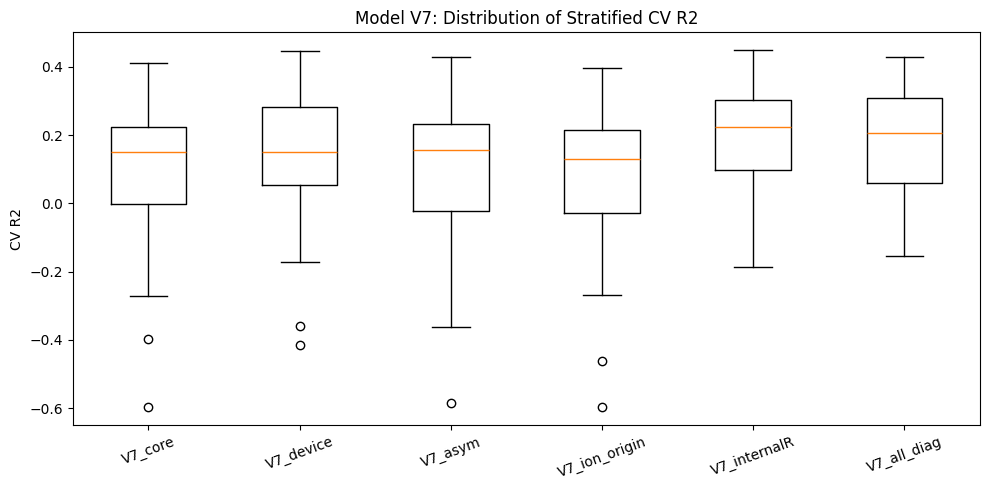

In [17]:
# CV distribution
plot_cv_r2_distributions(results_v7)

In [18]:
# Fair comparison for internal resistance
results_v7_internalR_fair = fair_internalR_comparison(
    df_input=df_v7,
    base_features=features_v7_core,
    target=TARGET
)

summary_v7_internalR_fair = summarize_v7_results(results_v7_internalR_fair)
summary_v7_internalR_fair

Rows in fair internal-R subset: 112

===== V7_core_on_internalR_subset =====
Rows used: 112
Raw features: 16
Encoded features: 84
Holdout R2: -0.0992
Holdout RMSE: 1.3459
Holdout MAE: 1.0802
CV R2 mean ± std: 0.0788 ± 0.3008
CV R2 min / max: -1.1209 / 0.5834

===== V7_core_plus_internalR_on_same_subset =====
Rows used: 112
Raw features: 17
Encoded features: 85
Holdout R2: 0.1288
Holdout RMSE: 1.1982
Holdout MAE: 0.9536
CV R2 mean ± std: 0.1475 ± 0.2722
CV R2 min / max: -0.7227 / 0.6356


,Model,Rows_used,Raw_features,Encoded_features,Holdout_R2,Holdout_RMSE,Holdout_MAE,CV_R2_mean,CV_R2_std,CV_R2_min,CV_R2_max,CV_RMSE_mean,CV_MAE_mean
0,plusR_same_subset,112,17,85,0.128802,1.198195,0.953609,0.147515,0.272188,-0.722681,0.635557,1.121221,0.844554
1,base_same_subset,112,16,84,-0.099202,1.345885,1.080191,0.078773,0.300796,-1.120873,0.583368,1.164764,0.887123


Best V7 model: V7_internalR


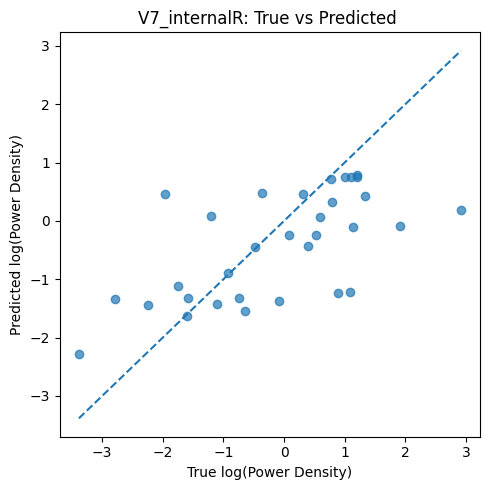

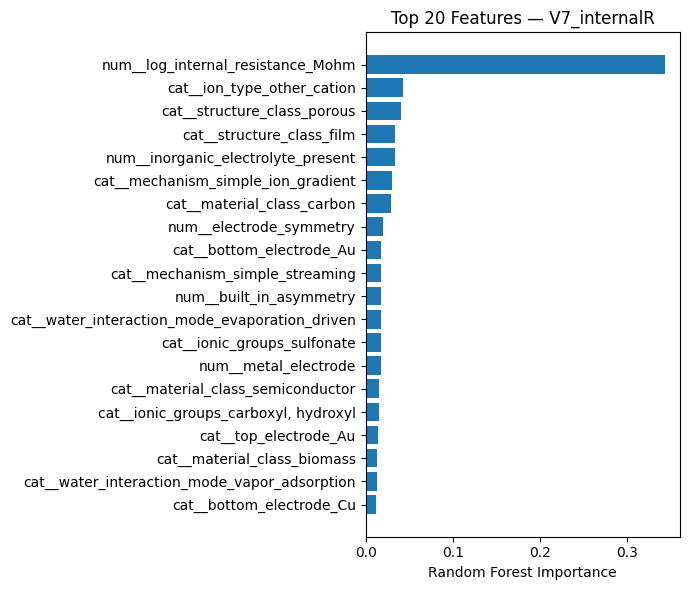

In [19]:
# Best model diagnostic plots
best_model_name = summary_v7.iloc[0]["Model"]
best_result_v7 = results_v7[best_model_name]

print("Best V7 model:", best_model_name)

plot_pred_vs_true(best_result_v7)
plot_top_importance(best_result_v7, top_n=20)

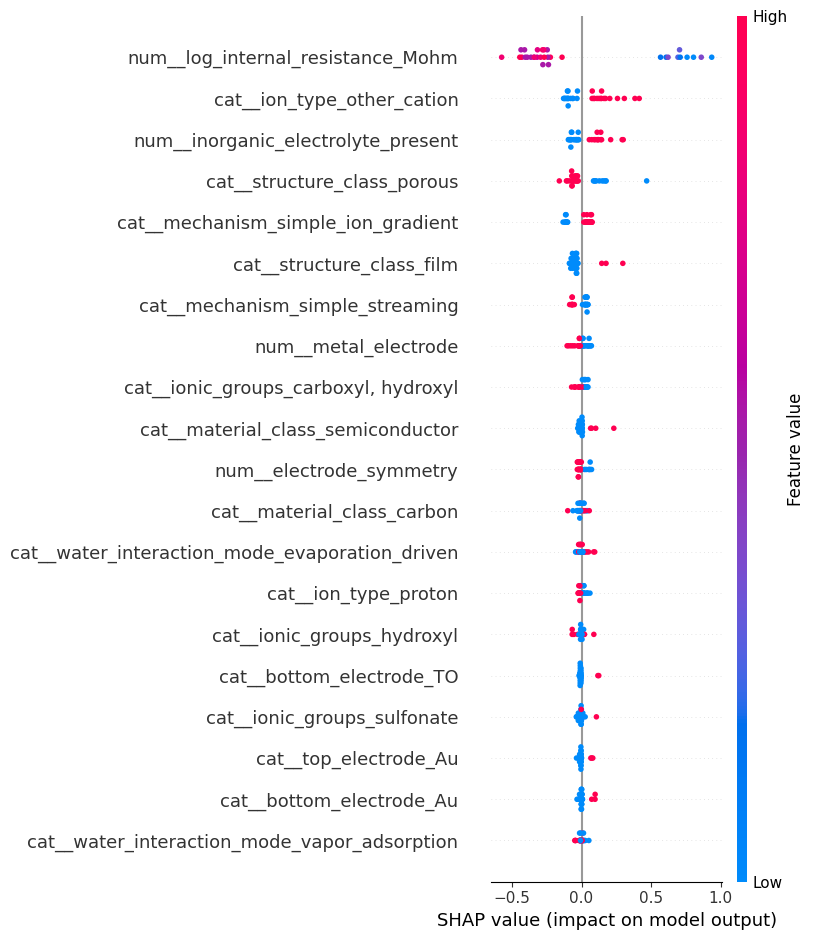

In [20]:
# SHAP for best V7 model
best_pipeline = best_result_v7["pipeline"]
best_preprocessor = best_pipeline.named_steps["preprocessor"]
best_rf = best_pipeline.named_steps["model"]

X_test_encoded = best_preprocessor.transform(best_result_v7["X_test"])

# Convert sparse matrix to dense if needed
if hasattr(X_test_encoded, "toarray"):
    X_test_encoded = X_test_encoded.toarray()

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=best_result_v7["feature_names"],
    index=best_result_v7["X_test"].index
)

explainer_v7 = shap.TreeExplainer(best_rf)
shap_values_v7 = explainer_v7.shap_values(X_test_encoded)

shap.summary_plot(shap_values_v7, X_test_encoded)

Ion-gradient subset size: 107

===== V7_ion_gradient_subset =====
Rows used: 107
Raw features: 18
Encoded features: 89
Holdout R2: 0.2490
Holdout RMSE: 1.1495
Holdout MAE: 0.8852
CV R2 mean ± std: 0.0679 ± 0.2305
CV R2 min / max: -0.7208 / 0.3895


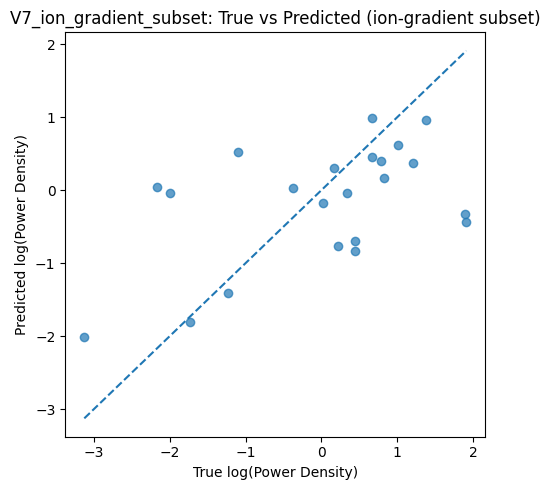

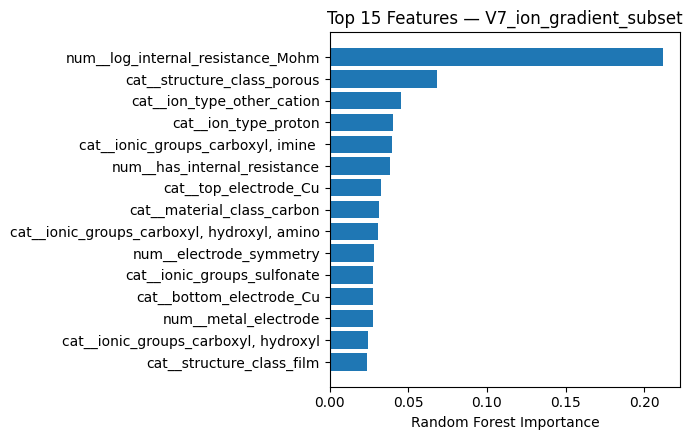

In [21]:
# Optional within-mechanism test
df_ig_v7 = df_v7[df_v7["mechanism_simple"] == "ion_gradient"].copy()
print("Ion-gradient subset size:", len(df_ig_v7))

if len(df_ig_v7) >= 40:
    features_ig = [
        "material_class",
        "structure_class",
        "built_in_asymmetry",
        "inorganic_electrolyte_present",
        "polyelectrolyte_present",
        "has_anionic",
        "has_cationic",
        "has_zwitterionic",
        "water_interaction_mode",
        "top_electrode",
        "bottom_electrode",
        "electrode_symmetry",
        "metal_electrode",
        "ionic_groups",
        "ion_type",
        "device_structure",
        "log_internal_resistance_Mohm",
        "has_internal_resistance"
    ]

    result_v7_ig = evaluate_rf_model_v7(
        df_input=df_ig_v7,
        features=features_ig,
        target=TARGET,
        stratify_col="ion_type",   # use ion_type instead
        model_name="V7_ion_gradient_subset",
        n_splits=30,
        test_size=0.2,
        holdout_random_state=42
    )

    plot_pred_vs_true(result_v7_ig, title_suffix="(ion-gradient subset)")
    plot_top_importance(result_v7_ig, top_n=15)
else:
    print("Subset too small for a stable within-mechanism diagnostic run.")

## Interpretation Notes for V7

Points to check after running the models:

1. Does `device_structure` improve CV mean R²?
2. Does `device_structure` reduce CV variance?
3. Does internal resistance still help under fair same-subset comparison?
4. Do asymmetry-related features add independent information beyond mechanism?
5. Do ion-origin features remain useful after mechanism is already included?
6. Does adding many diagnostic features increase instability?

Possible conclusions:
- true driver
- proxy variable
- noisy/confounded variable
- useful only within fixed mechanism regime

# Phase 1 — Final Summary

## 1. Objective of Phase 1
To construct a curated hydrovoltaic dataset and identify robust predictors of device performance using machine learning.

---

## 2. Key Methodological Improvements

- Target redefinition:  
  Power density estimated as P ≈ Voc × Jsc / 4, followed by log transformation

- Validation upgrade (Model V7):  
  - Repeated stratified ShuffleSplit (n=50)  
  - Reporting mean, std, min, max of CV R²  
  - Stability-focused evaluation instead of single-score comparison

---

## 3. Feature Diagnosis Summary

### Primary drivers (independent variables)
- mechanism_simple
- ion_type
- structure_class

### Integrated descriptor (performance-related)
- log_internal_resistance_Mohm  
  → strong predictive power  
  → physically coupled to transport and current output  

### Proxy variables
- device_structure  
  → reflects underlying mechanism and transport geometry  
  → limited independent contribution

### Noisy / unstable variables
- asymmetry-related features  
- ion_origin-related features  

---

## 4. Final Model Definition

### Model A — Mechanistic baseline
Features:
- mechanism_simple
- ion_type
- structure_class
(+ core features)

Purpose:
- Interpret physical drivers of hydrovoltaic performance

---

### Model B — Augmented model
Features:
- Model A + log_internal_resistance_Mohm

Purpose:
- Improve predictive performance using device-level descriptor

---

## 5. Key Scientific Insight

Hydrovoltaic performance is primarily governed by:

1. Ion transport mechanism
2. Ionic environment
3. Material structure

while many commonly used descriptors (e.g., device geometry, asymmetry labels)
act as secondary or proxy variables.

---

## 6. Conclusion

Phase 1 establishes a mechanism-oriented ML framework and identifies a minimal
set of robust predictors, forming the basis for Phase 2 multi-model comparison.

In [22]:
[c for c in df_v7.columns if "internal_resistance" in c]

['internal_resistance_MΩ',
 'log_internal_resistance_Mohm',
 'has_internal_resistance']

In [23]:
df_v7 = df_v7.rename(columns={
    "internal_resistance_MΩ": "internal_resistance_Mohm",
    "internal_resistance_MÎ©": "internal_resistance_Mohm",
    "internal_resistance_M??": "internal_resistance_Mohm"
})

In [24]:
[c for c in df_v7.columns if "internal_resistance" in c]

['internal_resistance_Mohm',
 'log_internal_resistance_Mohm',
 'has_internal_resistance']

In [25]:
df_v7.to_csv(
    "hydrovoltaic_dataset_phase2_input_utf8.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved: hydrovoltaic_dataset_phase2_input_utf8.csv")
# This file is used for all Phase 2 analyses.

Saved: hydrovoltaic_dataset_phase2_input_utf8.csv


In [26]:
df_check = pd.read_csv("hydrovoltaic_dataset_phase2_input_utf8.csv", encoding="utf-8-sig")
print(df_check.shape)
print([c for c in df_check.columns if "internal_resistance" in c])

(159, 52)
['internal_resistance_Mohm', 'log_internal_resistance_Mohm', 'has_internal_resistance']


## Final Phase 1 Dataset Definition

The dataset generated in this notebook is used as the fixed input for Phase 2 modeling.

Key characteristics:

- Rows: ~159 samples
- Target: log_estimated_power_density
- Mechanism labels: simplified into mechanism_simple
- Key engineered features:
  - log_internal_resistance_Mohm
  - has_internal_resistance
  - ion_type
  - structure_class
- Source identifier: paper_doi (used for grouped validation)

This dataset is treated as frozen for all subsequent analyses.